In [ ]:
# Step 1: Specify the path to the "experiment_analyses" folder in your system (after cloning the repo)
# This step is because I have a separate folder in the repo that contains the Jupyter Notebooks for organization purposes
import warnings
import os
experiment_analyses_dir = r"C:\Users\graci\OneDrive\Documents\Github\driving_exp_1_analyses\experiment_analyses"  # Replace with your desired directory
os.chdir(experiment_analyses_dir)


# Step 2: Specify the location of file paths contain the main_data folder
# I will share a Dropbox folder with you that contains these folders, so you can just copy and paste your file system file path to these
# Note that the files in these folders should be treated as immutable
import preprocess

SUBJECT_PATH = "C:/Users/graci/Dropbox/PAndA/Thesis Experiment 2/data/main_data" # Dropbox directory path that leads to the csv files for all subejcts across both familiar and unfamiliar group

# subject_dict: all keys are of each subject's id (e.g. "wad") and all values are of the subject_object (which will contain all the data for the subject)

warnings.filterwarnings("ignore")
subject_dict = preprocess.run(SUBJECT_PATH)

In [ ]:
# Useful references -------------------------
familiar_group_ids = ["baggy", "bash", "boned", "cargo","five", "grip", "mule", "polio", "rerun", "slate", "slept", "trial", "yeast"] 
unfamiliar_group_ids = ["atom", "brim", "chef", "clerk", "debt", "grid", "lens", "limb", "most","slimy", "swarm", "wok"]
track_pieces_of_interest = ['triple_s','symmetric_parabolic','t_turn','spiral'] # track segments for trial 10 analysis
track_piece_id = 't_turn'

In [ ]:
# Visualize problematic reset cases


In [ ]:
familiar_trajectories = []
unfamiliar_trajectories = []
for group in [familiar_group_ids, unfamiliar_group_ids]:
    for subject_id in group:
        # Get objects associated with a given subject and their trial
        subject_object = subject_dict[subject_id] 
        trial_object_ten = subject_object.trials[9]
        # Get trajectory for track segment of interest
        track_piece_object_dict = trial_object_ten.pieces # dictionary that contains track_piece names and their associated track_piece_object instantiation
        track_piece_object = track_piece_object_dict[track_piece_id] # get the track piece object associated to the track piece
        # Get the centerline for reference
        track_piece_center_x, track_piece_center_y = track_piece_object.centerline_df['x'],track_piece_object.centerline_df['y']
        # Get trajectory for a given piece
        track_piece_trajectory_df = track_piece_object.trajectory_df
        if len(familiar_trajectories) != len(familiar_group_ids): # checks when to switch to other experimental group list
            familiar_trajectories.append(track_piece_trajectory_df[['pos_x', 'pos_z']].values) # converts dataframe to np values
        else:
            unfamiliar_trajectories.append(track_piece_trajectory_df[['pos_x', 'pos_z']].values)

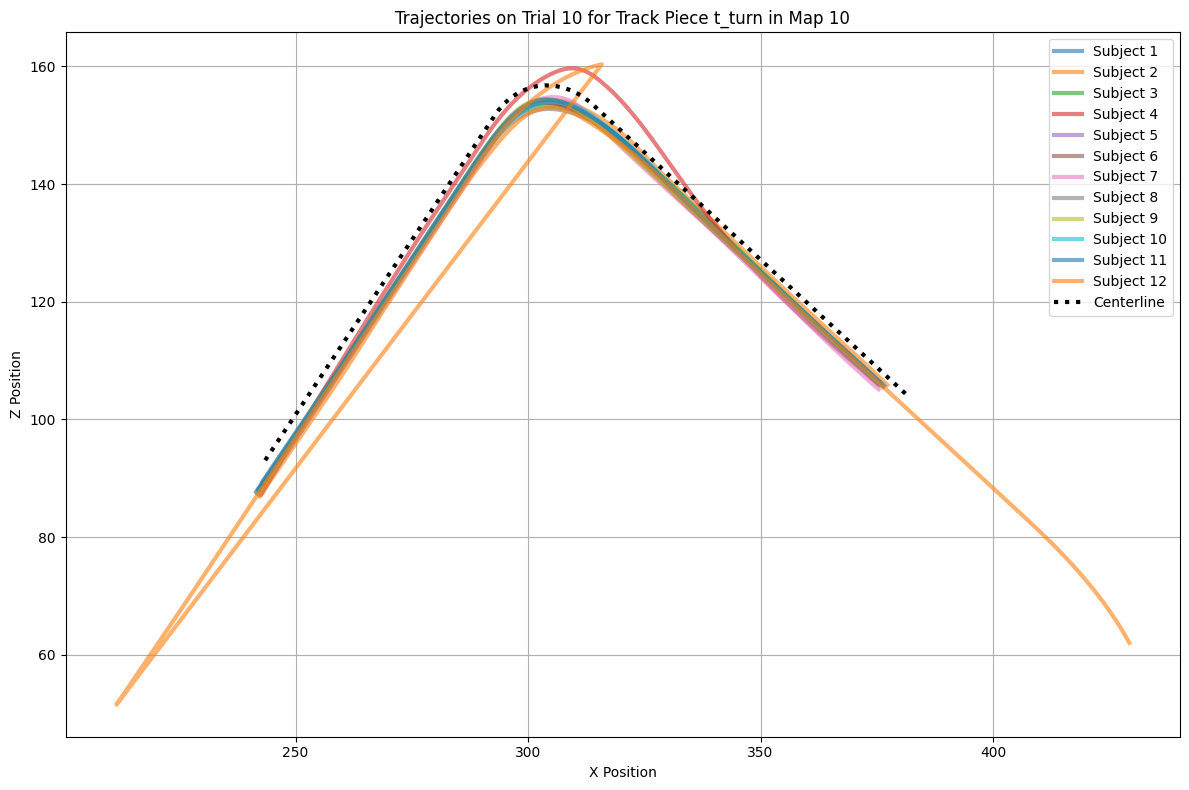

In [19]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 8))

# Plot all subject trajectories in red
for i, traj in enumerate(familiar_trajectories[0:12]):
    plt.plot(traj[:, 0], traj[:, 1], lw=3, label=f'Subject {i+1}', alpha=0.6)

# Plot the centerline
plt.plot(track_piece_center_x, track_piece_center_y, color='black', linestyle='dotted', lw=3, label='Centerline')

# Plotting labels
plt.title(f'Trajectories on Trial 10 for Track Piece {track_piece_object.id} in Map 10')
plt.xlabel('X Position')
plt.ylabel('Z Position')
plt.grid(True)
plt.tight_layout()
plt.legend()
plt.show()
